# CLIP → MedCLIP: маленькая версия на открытых данных

**Задание:** реализовать и обучить уменьшенный CLIP, сравнить *zero-shot*, *linear probe* и *few-shot*, проверить перенос на новые данные и воспроизвести адаптацию MedCLIP на рентгенах грудной клетки

## Этап 0. Подготовка окружения


In [ ]:
from pathlib import Path
import math, random, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import torch, torchvision
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score

from clip_medclip_refactored.config import *
from clip_medclip_refactored.utils import *
from clip_medclip_refactored.data import *
from clip_medclip_refactored.text import *
from clip_medclip_refactored.miniclip import *
from clip_medclip_refactored.prompts import *
from clip_medclip_refactored.medclip import *
from clip_medclip_refactored.evaluation import *

sns.set_theme(style="whitegrid")
print("torch      :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("pandas     :", pd.__version__)
print("Считаем на:", DEVICE)


In [ ]:
print("Проверка устройства:", DEVICE)
x = torch.randn(1000, 1000, device=DEVICE)
y = x @ x
print("Проверка прошла:", tuple(y.shape), "на устройстве", y.device)


Настройки проекта


Seed (сид) — число, которое «фиксирует случайность»: с одним и тем же сидом нейросеть стартует из одной и той же точки.
 Мы будем обучать модель с разными сидами и усреднять результат, чтобы вывод не зависел от удачного или неудачного старта.

In [ ]:
rad = prepare_radiography_splits(split_seed=13)
all_df = rad["all_df"]
split_df = rad["split_df"]
train_bin, val_bin, test_bin = rad["train_bin"], rad["val_bin"], rad["test_bin"]

print("Папка проекта:", ROOT)
print("Данные       :", DATA_ROOT)
print("Всего уникальных снимков:", len(all_df))


## Этап 1. Знакомство с данными. EDA

COVID-19 Radiography Database (Rahman et al., 2021): рентгены грудной клетки четырёх классов.

| Класс | Что это |
|---|---|
| `COVID` | COVID-19 |
| `Normal` | здоровые лёгкие |
| `Lung_Opacity` | другие поражения лёгких (не COVID) |
| `Viral Pneumonia` | вирусная пневмония |

В каждой папке класса лежат две подпапки: `images` (сами снимки) и `masks` (чёрно-белые маски, которые показывают, где на снимке лёгкие).

Перед обучением обязательно смотрим на данные: считаем, рисуем, ищем странности. Ошибки в данных незаметно портят любой результат.

In [4]:
CLASSES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

rows = []
for cls in CLASSES:
    img_files  = sorted((DATA_ROOT / cls / "images").glob("*.png"))
    mask_files = sorted((DATA_ROOT / cls / "masks").glob("*.png"))
    all_png    = list((DATA_ROOT / cls).rglob("*.png"))      # так считал старый код

    same_names = {p.name for p in img_files} == {p.name for p in mask_files}
    rows.append({
        "класс": cls,
        "снимков (images)": len(img_files),
        "масок (masks)": len(mask_files),
        "все png в папке класса": len(all_png),
        "у каждого снимка есть маска": same_names,
    })

counts_df = pd.DataFrame(rows)
counts_df

,класс,снимков (images),масок (masks),все png в папке класса,у каждого снимка есть маска
0,COVID,3616,3616,7232,True
1,Normal,10192,10192,20384,True
2,Lung_Opacity,6012,6012,12024,True
3,Viral Pneumonia,1345,1345,2690,True


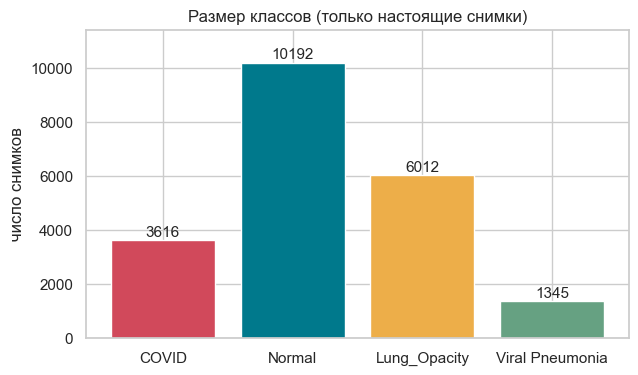

In [5]:
#  сколько снимков в каждом классе
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts_df["класс"], counts_df["снимков (images)"],
              color=["#d1495b", "#00798c", "#edae49", "#66a182"])
for bar, n in zip(bars, counts_df["снимков (images)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 150, str(n), ha="center", fontsize=11)
ax.set_ylabel("число снимков")
ax.set_title("Размер классов (только настоящие снимки)")
ax.set_ylim(0, counts_df["снимков (images)"].max() * 1.12)
save_fig("01_class_counts")
plt.show()


В основном эксперименте мы будем отличать **COVID от Normal**. 

Классов неравное количество. Посчитаем, какая точность получится, если модель вообще ничего не умеет и всегда отвечает «Normal».

In [6]:
n_covid  = int(counts_df.set_index("класс").loc["COVID",  "снимков (images)"])
n_normal = int(counts_df.set_index("класс").loc["Normal", "снимков (images)"])
total    = n_covid + n_normal

baseline_acc = n_normal / total
print(f"COVID : {n_covid}  ({n_covid / total:.1%})")
print(f"Normal: {n_normal}  ({n_normal / total:.1%})")
print()
print(f"Если всегда отвечать 'Normal', accuracy = {baseline_acc:.3f}")
print("Balanced accuracy у такого ответа = 0.500 (это уровень случайного угадывания)")

COVID : 3616  (26.2%)
Normal: 10192  (73.8%)

Если всегда отвечать 'Normal', accuracy = 0.738
Balanced accuracy у такого ответа = 0.500 (это уровень случайного угадывания)


**Вывод:** обычная *accuracy* здесь обманчива. Модель, которая всегда говорит «Normal», получает ≈0.74 и при этом бесполезна. Поэтому главной метрикой будет **balanced accuracy** (среднее от «доли найденных COVID» и «доли найденных Normal»): у бесполезной модели она равна 0.5, у идеальной 1.0.

### 1.1. Снимки и маски


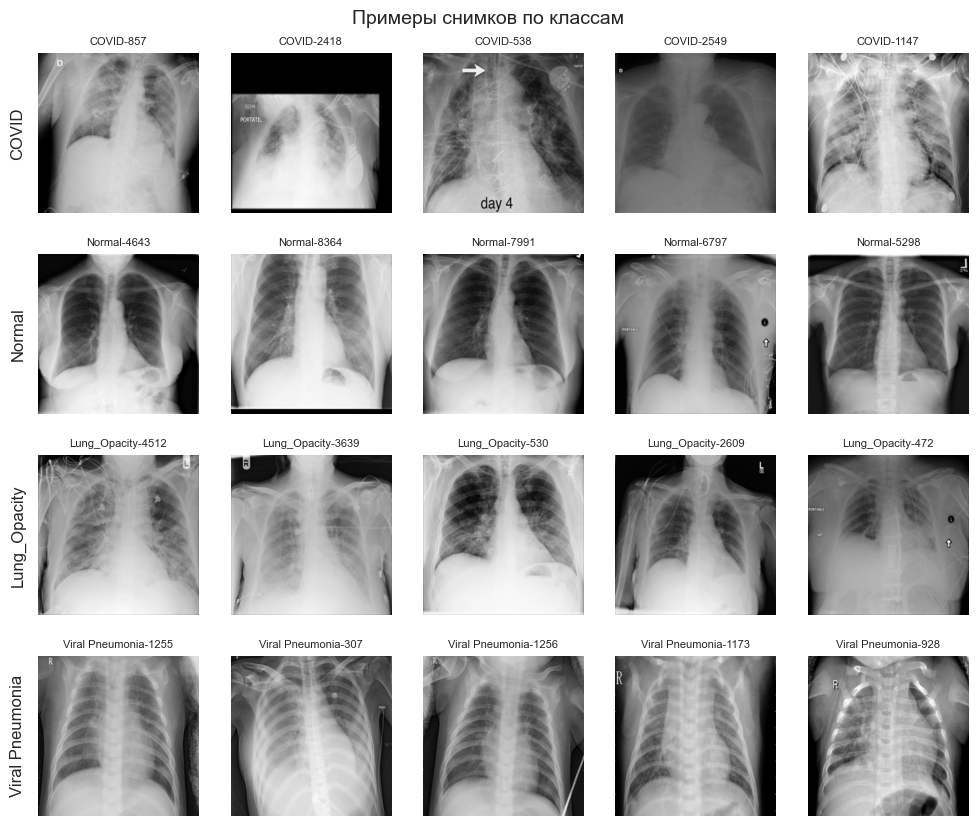

In [7]:
rng = random.Random(0)
n_show = 5

fig, axes = plt.subplots(len(CLASSES), n_show, figsize=(12, 10))
for i, cls in enumerate(CLASSES):
    files = sorted((DATA_ROOT / cls / "images").glob("*.png"))
    for j, path in enumerate(rng.sample(files, n_show)):
        axes[i, j].imshow(Image.open(path).convert("L"), cmap="gray")
        axes[i, j].set_title(path.stem, fontsize=8)
        axes[i, j].axis("off")
    # подпись класса слева от строки
    axes[i, 0].text(-0.08, 0.5, cls, transform=axes[i, 0].transAxes,
                    rotation=90, va="center", ha="right", fontsize=12)

plt.suptitle("Примеры снимков по классам", y=0.92, fontsize=14)
save_fig("02_examples")
plt.show()



Для наглядности: снимок, его маска и маска, наложенная на снимок. Мы **не используем маски для обучения**

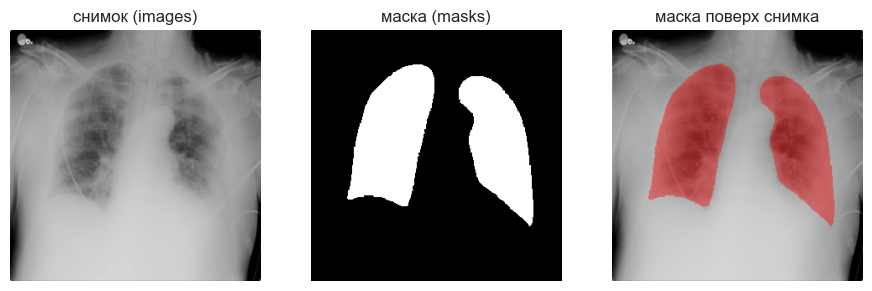

In [8]:
example_name = "COVID-1.png"
img  = Image.open(DATA_ROOT / "COVID" / "images" / example_name).convert("L")
mask = Image.open(DATA_ROOT / "COVID" / "masks"  / example_name).convert("L")
if mask.size != img.size:                      # на всякий случай приводим к одному размеру
    mask = mask.resize(img.size)

img_arr  = np.asarray(img)
mask_arr = np.asarray(mask) > 127              # True там, где «лёгкие»

# Наложение: красим область маски в красный цвет
overlay = np.stack([img_arr] * 3, axis=-1).astype(np.float32)
overlay[mask_arr] = overlay[mask_arr] * 0.6 + np.array([255, 0, 0]) * 0.4

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(img_arr, cmap="gray");          axes[0].set_title("снимок (images)")
axes[1].imshow(mask_arr, cmap="gray");         axes[1].set_title("маска (masks)")
axes[2].imshow(overlay.astype(np.uint8));      axes[2].set_title("маска поверх снимка")
for ax in axes:
    ax.axis("off")
save_fig("03_mask_example")
plt.show()

Размер, формат и яркость снимков

Берём по 200 случайных снимков из каждого класса и смотрим:
- одинаковый ли у всех размер и цветовой режим (нам нужно подать модели картинки одного размера);
- не отличаются ли классы по средней яркости. Если отличаются, модель может «жульничать» и угадывать класс по яркости, а не по болезни.

In [9]:
rng = random.Random(1)
prop_rows = []
for cls in CLASSES:
    files = sorted((DATA_ROOT / cls / "images").glob("*.png"))
    for path in rng.sample(files, 200):
        with Image.open(path) as im:
            size, mode = im.size, im.mode
            arr = np.asarray(im.convert("L"), dtype=np.float32) / 255.0
        prop_rows.append({
            "класс": cls,
            "размер": f"{size[0]}x{size[1]}",
            "режим": mode,
            "средняя яркость": arr.mean(),
            "контраст (std)": arr.std(),
        })
prop_df = pd.DataFrame(prop_rows)

print("Размеры и режимы (по выборке 4 x 200 снимков):")
print(prop_df.groupby(["размер", "режим"]).size().to_string())

Размеры и режимы (по выборке 4 x 200 снимков):
размер   режим
299x299  L        778
         RGB       22


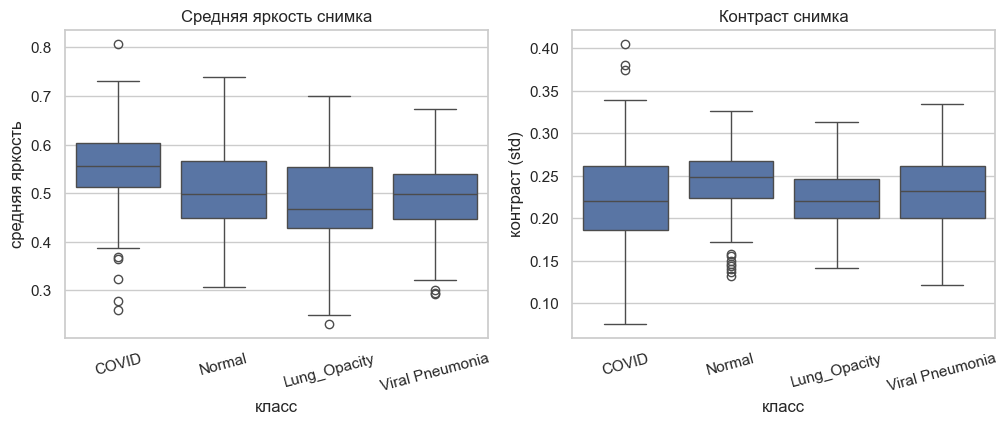

,средняя яркость,контраст (std)
класс,,
COVID,0.551,0.223
Lung_Opacity,0.488,0.223
Normal,0.512,0.242
Viral Pneumonia,0.490,0.230


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=prop_df, x="класс", y="средняя яркость", ax=axes[0])
axes[0].set_title("Средняя яркость снимка")
sns.boxplot(data=prop_df, x="класс", y="контраст (std)", ax=axes[1])
axes[1].set_title("Контраст снимка")
for ax in axes:
    ax.tick_params(axis="x", rotation=15)
save_fig("04_brightness_contrast")
plt.show()

prop_df.groupby("класс")[["средняя яркость", "контраст (std)"]].mean().round(3)

### 1.2. Откуда взяты снимки (метаданные)

В датасете рядом с папками лежат таблицы `*.metadata.xlsx` со ссылкой на источник каждого снимка. Это важно: если один класс собран из одних источников, а другой из других, то модель может научиться отличать **источник**, а не болезнь.

In [11]:
meta_parts = []
for cls in CLASSES:
    m = pd.read_excel(DATA_ROOT / f"{cls}.metadata.xlsx")
    m["класс"] = cls
    meta_parts.append(m)
meta = pd.concat(meta_parts, ignore_index=True)

# Из ссылки вытаскиваем только название сайта (домен)
meta["источник"] = meta["URL"].astype(str).str.extract(r"https?://(?:www\.)?([^/]+)")[0]

# Таблица: сколько снимков каждого класса пришло с каждого сайта
sources = pd.crosstab(meta["класс"], meta["источник"])
sources

источник,bimcv.cipf.es,eurorad.org,github.com,kaggle.com,sirm.org
класс,,,,,
COVID,2474,258,765,0,119
Lung_Opacity,0,0,0,6012,0
Normal,0,0,0,10192,0
Viral Pneumonia,0,0,0,1345,0


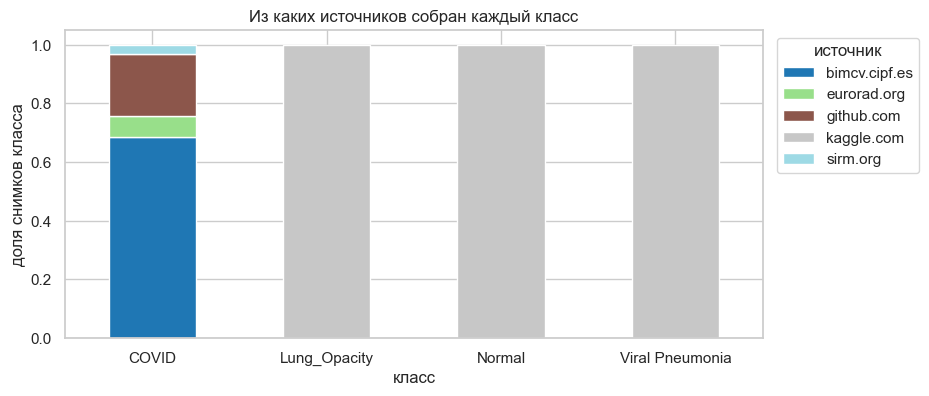

In [12]:
# То же в виде столбиков (доля каждого источника внутри класса)
share = sources.div(sources.sum(axis=1), axis=0)
ax = share.plot(kind="bar", stacked=True, figsize=(9, 4), colormap="tab20")
ax.set_ylabel("доля снимков класса")
ax.set_title("Из каких источников собран каждый класс")
ax.legend(title="источник", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
save_fig("05_sources")
plt.show()

**Что видно:** `Normal`, `Lung_Opacity` и `Viral Pneumonia` собраны с одного сайта (Kaggle), а `COVID` в основном из других источников (BIMCV, GitHub, Eurorad и др.). Значит, у COVID и Normal разные «почерки» съёмки, и высокий результат модели нужно трактовать осторожно: часть успеха может объясняться различием источников.

Ещё COVID в среднем чуть ярче остальных . Всё это «подсказки», по которым модель может угадывать класс, не разбираясь в болезни.

## Этап 2. train / val / test


1. Делим один раз  и сохраняем в файл. Тогда все модели (CLIP, MedCLIP, разные сиды) сдают один и тот же экзамен, и их можно честно сравнивать.
2. Делим стратифицированно: в каждой части одинаковая доля каждого класса. Иначе в тесте случайно может оказаться слишком мало COVID.



In [ ]:
split_counts = pd.crosstab(split_df["class_name"], split_df["split"])[["train", "val", "test"]]
split_counts["всего"] = split_counts.sum(axis=1)
split_counts.loc["ИТОГО"] = split_counts.sum()
split_counts


### 2.2. Ищем и убираем точные копии

Если один и тот же снимок попадёт и в train, и в test, то модель на экзамене получит «шпаргалку», и результат будет завышен. Точные копии ищем по «отпечатку» файла — **md5-хешу**: два одинаковых файла дают один и тот же хеш.

In [ ]:
dup = rad["duplicate_info"]
print("Групп одинаковых файлов  :", dup["n_groups"])
print("Снимков в этих группах   :", dup["n_files"])
print("Группы с РАЗНЫМИ классами:", dup["cross_class_groups"], "(0 = конфликтов меток нет)")
print()
print("В каких классах встречаются копии:")
print(dup["class_counts"].to_string())


In [ ]:
# Дубликаты уже удалены в `prepare_radiography_splits`; здесь только фиксируем итог.

### 2.3. Делим на train / val / test

In [ ]:
# Фиксированное разбиение уже создано/загружено в `prepare_radiography_splits`.

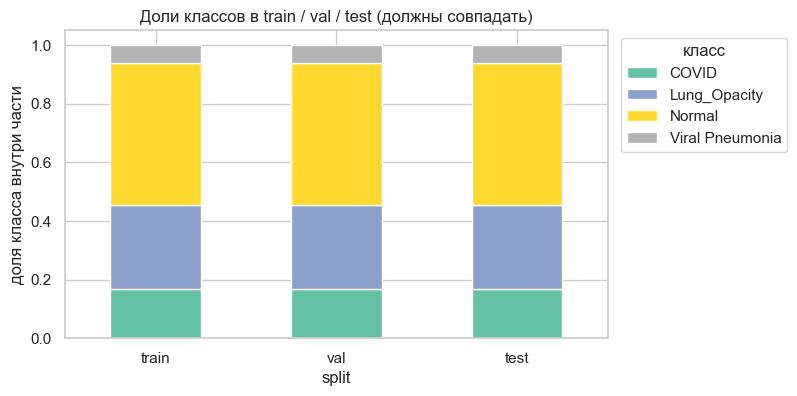

In [17]:
# Доля каждого класса должна быть почти одинаковой во всех частях
share = pd.crosstab(split_df["split"], split_df["class_name"], normalize="index")
share = share.loc[["train", "val", "test"]]

ax = share.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="Set2")
ax.set_ylabel("доля класса внутри части")
ax.set_title("Доли классов в train / val / test (должны совпадать)")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="класс", bbox_to_anchor=(1.01, 1), loc="upper left")
save_fig("06_split_shares")
plt.show()

###  Данные для основного эксперимента: COVID против Normal

Из общей таблицы берём два класса и вводим числовую метку: **COVID = 1, Normal = 0**.

In [ ]:
for name, d in [("train", train_bin), ("val", val_bin), ("test", test_bin)]:
    print(f"{name:5s}: {len(d):5d} снимков, доля COVID = {d['label'].mean():.1%}")
print()
print("Базовый ответ 'всегда Normal' на тесте даёт accuracy =",
      round(1 - test_bin["label"].mean(), 3), "и balanced accuracy = 0.5")


## Этап 3. MiniCLIP на CIFAR-10 и перенос на CIFAR-100

**Как учится CLIP.** Две сети: картинка → вектор и текст → вектор. Учим на парах «картинка + подпись». Для пачки из 64 пар считаем таблицу похожести 64×64 и добиваемся, чтобы большие значения стояли на диагонали (правильные пары). Это *contrastive loss*.


In [ ]:
# Архитектура и служебные константы MiniCLIP вынесены в `miniclip.py`.

### Текст и словарь

токенайзер заменяет слова номерами из словаря, незнакомые слова превращаются в `<unk>`. Словарь строим по тем же текстам, что у коллеги, иначе её веса не подойдут по размеру.

In [ ]:
tokenizer = SimpleTextTokenizer(CIFAR10_PROMPTS + VOCAB_EXTRA_TEXTS)
print("Размер словаря:", len(tokenizer.stoi))


### Модель MiniCLIP



In [ ]:
# SmallTextEncoder, SmallImageEncoder, MiniCLIP и clip_loss вынесены в `miniclip.py`.

###  Данные

CIFAR-10 (10 классов, на них учили) и CIFAR-100 (100 других классов, модель их не видела). Torchvision скачает оба (~330 МБ).

In [ ]:
CIFAR_DIR = ROOT / "data" / "cifar"
cifar = load_cifar_experiment(CIFAR_DIR)
c10_train_x, c10_train_y = cifar["c10_train_x"], cifar["c10_train_y"]
c10_test_x, c10_test_y = cifar["c10_test_x"], cifar["c10_test_y"]
c100_train_x, c100_train_y = cifar["c100_train_x"], cifar["c100_train_y"]
c100_test_x, c100_test_y = cifar["c100_test_x"], cifar["c100_test_y"]
C10_NAMES, C100_NAMES = cifar["C10_NAMES"], cifar["C100_NAMES"]
assert C10_NAMES == CIFAR10_NAMES
print(f"CIFAR-10 : train {len(c10_train_x)}, test {len(c10_test_x)}, классов {len(C10_NAMES)}")
print(f"CIFAR-100: train {len(c100_train_x)}, test {len(c100_test_x)}, классов {len(C100_NAMES)}")


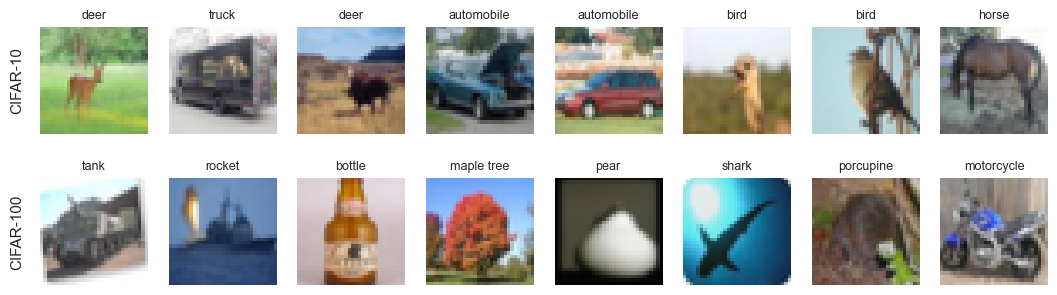

In [24]:
# Посмотрим на картинки: сверху CIFAR-10 (эти классы модель знает), снизу CIFAR-100 (новые классы)
fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
rng = np.random.default_rng(0)
for row, (x, y, names, title) in enumerate([(c10_test_x, c10_test_y, C10_NAMES, "CIFAR-10"),
                                             (c100_test_x, c100_test_y, C100_NAMES, "CIFAR-100")]):
    for col, i in enumerate(rng.choice(len(x), 8, replace=False)):
        axes[row, col].imshow(x[i].numpy())
        axes[row, col].set_title(names[int(y[i])].replace("_", " "), fontsize=9)
        axes[row, col].axis("off")
    axes[row, 0].text(-0.15, 0.5, title, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="right", fontsize=11)
save_fig("07_cifar_examples")
plt.show()

###  Веса

`load_miniclip(seed)` загружает готовый чекпоинт, а если его нет, обучает модель (20 эпох, AdamW)

In [ ]:
# Загрузка/обучение MiniCLIP и работа с чекпоинтами вынесены в `miniclip.py`.

### Способы оценки

- **zero-shot:** сравниваем вектор картинки с векторами подписей классов, ничего не доучиваем (top-1 и top-5);
- **linear probe:** замораживаем модель, на векторах картинок учим линейный классификатор на всех train-картинках;
- **few-shot:** то же, но по k картинок на класс (k = 1…16).

In [ ]:
# Извлечение признаков, zero-shot и few-shot/linear-probe helpers вынесены в `miniclip.py`.

### Почему zero-shot на CIFAR-100 невозможен

Смотрим, что видит текстовая часть модели для названий классов CIFAR-100.

In [27]:
examples = ["cat", "apple", "maple_tree", "aquarium_fish", "bus"]
for name in examples:
    prompt = make_prompt(name)
    ids = [tokenizer.stoi.get(w, tokenizer.unk) for w in tokenizer.tokenize(prompt)]
    print(f"{prompt:32s} -> {ids}")

print()
# Сколько РАЗНЫХ подписей реально различает модель среди 100 классов CIFAR-100?
unique_texts = {tuple(tokenizer.encode(make_prompt(n)).tolist()) for n in C100_NAMES}
n_known = sum(w in tokenizer.stoi for n in C100_NAMES for w in tokenizer.tokenize(make_prompt(n)))
print("Классов в CIFAR-100                                :", len(C100_NAMES))
print("Разных последовательностей чисел у их подписей     :", len(unique_texts))
print("Из названий классов в словаре есть слов            :",
      sum(w in tokenizer.stoi for n in C100_NAMES for w in tokenizer.tokenize(n.replace('_', ' '))))

a photo of a cat                 -> [2, 17, 16, 2, 6]
a photo of a apple               -> [2, 17, 16, 2, 1]
a photo of a maple tree          -> [2, 17, 16, 2, 1, 1]
a photo of a aquarium fish       -> [2, 17, 16, 2, 1, 1]
a photo of a bus                 -> [2, 17, 16, 2, 1]

Классов в CIFAR-100                                : 100
Разных последовательностей чисел у их подписей     : 3
Из названий классов в словаре есть слов            : 1


**Что видно:** `1` — это `<unk>`. Незнакомые названия превращаются в него, поэтому разные классы CIFAR-100 неразличимы для текстовой части, и zero-shot должен дать ≈1% (случайное угадывание). Настоящий CLIP справляется, потому что его текстовая часть обучена на сотнях миллионов подписей. Качество *картинок* проверяем без текста: linear probe и few-shot.

### Эксперимент: 10 сидов

Для каждого сида считаем обученную модель и модель без обучения (случайные веса, контроль): zero-shot, linear probe и few-shot (k = 1…16) на CIFAR-10 и CIFAR-100.

In [ ]:
FEW_SHOT_KS = [1, 2, 4, 8, 16]
MODEL_TRAINED   = "MiniCLIP (обучена)"
MODEL_UNTRAINED = "MiniCLIP (без обучения)"

results = []          # сюда складываем все числа: одна строка = одно измерение
first_seed_sims = None

def add(model_name, dataset, method, seed, metric, value):
    results.append({"model": model_name, "dataset": dataset, "method": method,
                    "seed": seed, "metric": metric, "value": value})

for seed in tqdm(SEEDS, desc="сиды"):
    for model_name, model in [(MODEL_TRAINED, load_miniclip(seed, c10_train_x, c10_train_y, tokenizer)),
                              (MODEL_UNTRAINED, make_untrained(seed, tokenizer))]:
        # 1) Векторы всех картинок (считаем один раз, дальше используем много раз)
        f = {
            "c10_train":  image_features(model, c10_train_x),
            "c10_test":   image_features(model, c10_test_x),
            "c100_train": image_features(model, c100_train_x),
            "c100_test":  image_features(model, c100_test_x),
        }

        # 2) Zero-shot
        top1, top5, sims = zero_shot(model, f["c10_test"], c10_test_y.numpy(), C10_NAMES, tokenizer)
        add(model_name, "CIFAR-10", "zero-shot", seed, "accuracy", top1)
        add(model_name, "CIFAR-10", "zero-shot", seed, "top5_accuracy", top5)
        if seed == SEEDS[0] and model_name == MODEL_TRAINED:
            first_seed_sims = sims                       # пригодится для матрицы ошибок

        top1, top5, _ = zero_shot(model, f["c100_test"], c100_test_y.numpy(), C100_NAMES, tokenizer)
        add(model_name, "CIFAR-100", "zero-shot", seed, "accuracy", top1)
        add(model_name, "CIFAR-100", "zero-shot", seed, "top5_accuracy", top5)

        # 3) Linear probe и few-shot: для обоих датасетов
        for ds_name, tr_x, tr_y, te_x, te_y in [
            ("CIFAR-10",  f["c10_train"],  c10_train_y.numpy(),  f["c10_test"],  c10_test_y.numpy()),
            ("CIFAR-100", f["c100_train"], c100_train_y.numpy(), f["c100_test"], c100_test_y.numpy()),
        ]:
            add(model_name, ds_name, "linear-probe", seed, "accuracy",
                fit_and_score(tr_x, tr_y, te_x, te_y, seed))

            rng = np.random.default_rng(seed)
            for k in FEW_SHOT_KS:
                idx = sample_k_per_class(tr_y, k, rng)
                add(model_name, ds_name, f"{k}-shot", seed, "accuracy",
                    fit_and_score(tr_x[idx], tr_y[idx], te_x, te_y, seed))

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_DIR / "stage3_miniclip_cifar.csv", index=False)
print("Готово. Строк в таблице результатов:", len(results_df))

###  Результаты

Среднее ± std по 10 сидам.

In [29]:
METHOD_ORDER = ["zero-shot"] + [f"{k}-shot" for k in FEW_SHOT_KS] + ["linear-probe"]

acc = results_df[results_df["metric"] == "accuracy"]
stats = acc.groupby(["dataset", "method", "model"])["value"].agg(["mean", "std"])
stats["итог"] = stats.apply(lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1)

table = stats["итог"].unstack("model")[[MODEL_TRAINED, MODEL_UNTRAINED]]
table = table.reindex(pd.MultiIndex.from_product([["CIFAR-10", "CIFAR-100"], METHOD_ORDER]))
table.index.names = ["датасет", "метод"]
table

model                  MiniCLIP (обучена) MiniCLIP (без обучения)
датасет   метод                                                  
CIFAR-10  zero-shot         0.556 ± 0.004           0.100 ± 0.000
          1-shot            0.303 ± 0.034           0.145 ± 0.024
          2-shot            0.344 ± 0.035           0.174 ± 0.012
          4-shot            0.401 ± 0.026           0.201 ± 0.012
          8-shot            0.425 ± 0.021           0.220 ± 0.011
          16-shot           0.431 ± 0.012           0.245 ± 0.015
          linear-probe      0.561 ± 0.005           0.366 ± 0.003
CIFAR-100 zero-shot         0.016 ± 0.001           0.010 ± 0.000
          1-shot            0.051 ± 0.004           0.034 ± 0.005
          2-shot            0.063 ± 0.004           0.048 ± 0.002
          4-shot            0.080 ± 0.004           0.059 ± 0.005
          8-shot            0.098 ± 0.003           0.077 ± 0.002
          16-shot           0.128 ± 0.004           0.096 ± 0.005
          linear-probe      0.202 ± 0.004           0.135 ± 0.004

In [30]:
# Отдельно: top-5 для zero-shot (угадал ли среди пяти лучших ответов)
top5 = (results_df[(results_df["metric"] == "top5_accuracy")]
        .groupby(["dataset", "model"])["value"].agg(["mean", "std"]).round(3))
print("Случайное угадывание: top-1 = 10% (CIFAR-10) и 1% (CIFAR-100); top-5 = 50% и 5%")
top5

Случайное угадывание: top-1 = 10% (CIFAR-10) и 1% (CIFAR-100); top-5 = 50% и 5%


mean    std
dataset   model                                
CIFAR-10  MiniCLIP (без обучения)  0.500  0.001
          MiniCLIP (обучена)       0.952  0.002
CIFAR-100 MiniCLIP (без обучения)  0.050  0.001
          MiniCLIP (обучена)       0.056  0.003

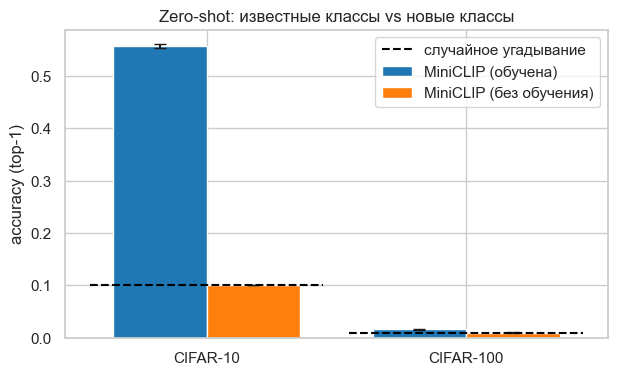

In [31]:
# График 1: zero-shot на CIFAR-10 и CIFAR-100
zs = results_df[(results_df["method"] == "zero-shot") & (results_df["metric"] == "accuracy")]
agg = zs.groupby(["dataset", "model"])["value"].agg(["mean", "std"]).reset_index()
datasets_order = ["CIFAR-10", "CIFAR-100"]
chance = {"CIFAR-10": 0.10, "CIFAR-100": 0.01}

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.36
for j, (model_name, color) in enumerate([(MODEL_TRAINED, "tab:blue"), (MODEL_UNTRAINED, "tab:orange")]):
    sub = agg[agg["model"] == model_name].set_index("dataset").loc[datasets_order]
    ax.bar(np.arange(2) + (j - 0.5) * width, sub["mean"], width, yerr=sub["std"],
           capsize=4, label=model_name, color=color)
for i, ds in enumerate(datasets_order):
    ax.hlines(chance[ds], i - 0.45, i + 0.45, colors="black", linestyles="--",
              label="случайное угадывание" if i == 0 else None)
ax.set_xticks(range(2)); ax.set_xticklabels(datasets_order)
ax.set_ylabel("accuracy (top-1)")
ax.set_title("Zero-shot: известные классы vs новые классы")
ax.legend()
save_fig("08_zero_shot_cifar")
plt.show()

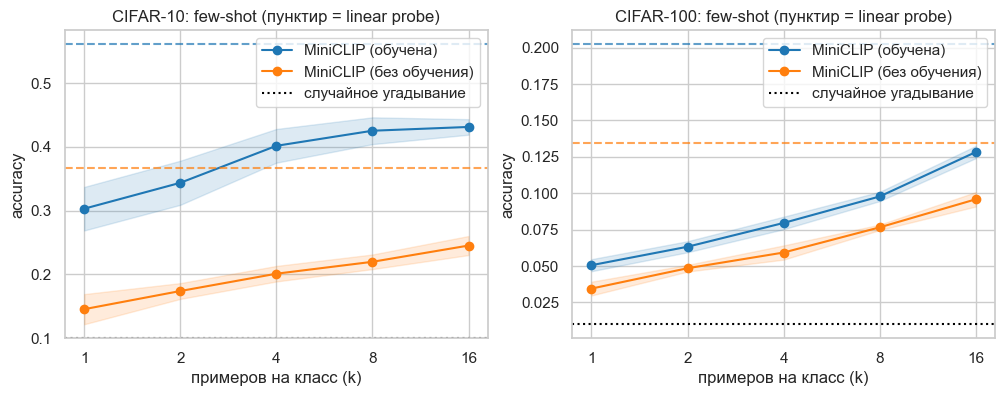

In [32]:
# График 2: few-shot и linear probe, чем больше примеров, тем лучше
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, ds in zip(axes, datasets_order):
    for model_name, color in [(MODEL_TRAINED, "tab:blue"), (MODEL_UNTRAINED, "tab:orange")]:
        sub = acc[(acc["dataset"] == ds) & (acc["model"] == model_name)]
        fs = (sub[sub["method"].str.endswith("-shot") & (sub["method"] != "zero-shot")]
              .assign(k=lambda d: d["method"].str.replace("-shot", "").astype(int))
              .groupby("k")["value"].agg(["mean", "std"]))
        ax.plot(fs.index, fs["mean"], marker="o", color=color, label=model_name)
        ax.fill_between(fs.index, fs["mean"] - fs["std"], fs["mean"] + fs["std"], color=color, alpha=0.15)
        lp = sub[sub["method"] == "linear-probe"]["value"].mean()
        ax.axhline(lp, color=color, linestyle="--", alpha=0.7)       # пунктир = linear probe на всех данных
    ax.axhline(chance[ds], color="black", linestyle=":", label="случайное угадывание")
    ax.set_xscale("log", base=2)
    ax.set_xticks(FEW_SHOT_KS); ax.set_xticklabels(FEW_SHOT_KS)
    ax.set_xlabel("примеров на класс (k)"); ax.set_ylabel("accuracy")
    ax.set_title(f"{ds}: few-shot (пунктир = linear probe)")
    ax.legend()
save_fig("09_fewshot_cifar")
plt.show()

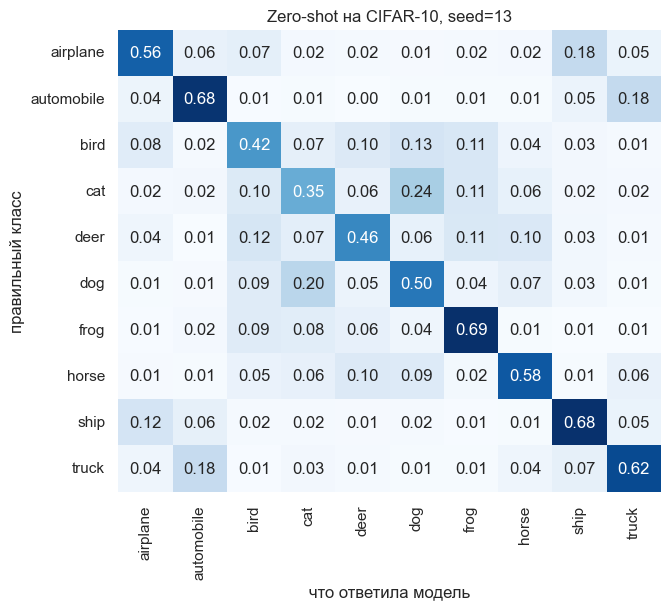

In [33]:
# Матрица ошибок zero-shot на CIFAR-10 (первый сид): какие классы модель путает
pred = first_seed_sims.argmax(axis=1)
cm = confusion_matrix(c10_test_y.numpy(), pred, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=C10_NAMES, yticklabels=C10_NAMES, ax=ax)
ax.set_xlabel("что ответила модель"); ax.set_ylabel("правильный класс")
ax.set_title(f"Zero-shot на CIFAR-10, seed={SEEDS[0]}")
save_fig("10_confusion_cifar10")
plt.show()

## Этап 4. Mini-MedCLIP: CLIP для рентгенов

### 4.1. Что такое MedCLIP и чем он отличается от обычного CLIP

**Проблема медицины.** Для обычного CLIP нужны миллионы пар «картинка + её описание». В медицине таких пар мало: отчёты врачей закрыты, а описание конкретного снимка редко есть в открытом доступе. Зато есть много снимков с метками («COVID», «норма») и отдельно много медицинских текстов.

**Идея MedCLIP (Wang et al., 2022)** состоит из трёх частей:

1. **Картинки и тексты берём независимо** (*decoupling*). Не нужно знать, какой текст «принадлежит» какому снимку. Мы просто берём пачку снимков и отдельно пачку текстов.
2. **Связь определяется по метке.** Снимок с меткой COVID подходит к любому тексту про COVID и не подходит к текстам про норму (и наоборот). Для этого каждому снимку и тексту присваивается *вектор меток* (у нас два числа: `[COVID, Normal]`).
3. **Мягкие цели (semantic matching loss).** В обычном CLIP «правильная» пара одна (по диагонали таблицы), а все остальные считаются неправильными. Здесь же *правильными считаются все пары с одинаковой меткой*. Это решает проблему ложных негативов: другой текст про COVID для снимка с COVID уже не «ошибка».

Как это выглядит в таблице похожестей «снимки × тексты» для пачки из 6 штук (1 = «пара правильная»):

| | текст: COVID | текст: Normal | текст: Normal | текст: COVID |
|---|---|---|---|---|
| **снимок: COVID** | 1 | 0 | 0 | 1 |
| **снимок: Normal** | 0 | 1 | 1 | 0 |

(В обычном CLIP единицы стояли бы только на диагонали.)


In [ ]:
MEDCLIP_EPOCHS = 20


### 4.3. Тексты: «пул» медицинских описаний

Настоящих отчётов у нас нет, поэтому мы вручную написали (нагенерили) пул коротких описаний в стиле рентгенологических заключений. 

Каждому тексту присвоена метка: `1` = про COVID, `0` = про норму. Во время обучения тексты не привязаны к снимкам, они просто выбираются случайно.

Отдельно задаём **подписи для zero-shot** (по 3 на класс). Это *другие* предложения, которых нет в пуле, но составленные из тех же слов (нейросеть не знает слов, которых не видела при обучении).

In [ ]:
tok_A, ids_A, sem_A = get_prompt_data("A_radiology")
PROMPT_SETS["A_radiology"]  # исходный набор хранится в prompts.py


### 4.4. Данные: рентгены в памяти

Берём разбиение из этапа 2 (`train_bin`, `val_bin`, `test_bin`: COVID против Normal). Чтобы не читать 299×299 PNG на каждой эпохе, один раз превращаем все снимки в серые картинки 64×64 и сохраняем в файлы-кэши (`cache/xray64_*.npy`). Первый запуск займёт пару минут, дальше загрузка мгновенная.

In [ ]:
xr = load_xray_splits(train_bin, val_bin, test_bin)
xr_train_x, xr_train_y = xr["train"]
xr_val_x, xr_val_y = xr["val"]
xr_test_x, xr_test_y = xr["test"]
for name in ["train", "val", "test"]:
    x, y = xr[name]
    print(f"{name:5s}: {tuple(x.shape)}  доля COVID = {y.float().mean():.1%}")


### 4.5. Аугментация

Чтобы модель не запоминала конкретные картинки и не цеплялась за случайные детали (яркость, положение), каждый раз немного меняем снимок:

- случайно отражаем, чуть поворачиваем, сдвигаем и приближаем ;
- случайно меняем яркость и контраст. На этапе 1 мы видели, что COVID чуть ярче остальных, и не хотим, чтобы модель угадывала болезнь по яркости.

In [ ]:
# Аугментация вынесена в `medclip.py`.


### 4.6. Loss с «мягкими целями» и два способа их посчитать

**Как работает loss.** Как и у CLIP, считаем таблицу «каждый снимок × каждый текст» из пачки (косинус между векторами). Потом сравниваем её с *целевой* таблицей: она говорит, какие пары должны быть похожи.

В обычном CLIP целевая таблица — единичная матрица. В MedCLIP она строится из **похожести меток**: если метки у снимка и текста совпали, похожесть 1, иначе 0. Остаётся решить, как превратить эти числа в вероятности (в каждой строке они должны давать в сумме 1). 


Есть два способа:

| Режим | Формула | Что получается |
|---|---|---|
| `softmax` | softmax от похожести (способ из первой версии) | «мягко»: у правильных пар вес всего в ~2.7 раза больше, чем у неправильных |
| `normalized` | похожесть делим на сумму по строке | «чётко»: вся вероятность делится только между правильными парами |

Ниже пример на пачке из 64 штук.

In [ ]:
# Цели и loss вынесены в `medclip.py`.
g = torch.Generator().manual_seed(0)
y_img = torch.randint(0, 2, (64,), generator=g)
y_txt = torch.randint(0, 2, (64,), generator=g)
lab_img = torch.stack([y_img, 1 - y_img], dim=1)
lab_txt = torch.stack([y_txt, 1 - y_txt], dim=1)
for mode in ["softmax", "normalized"]:
    t = semantic_targets(lab_img, lab_txt, mode)
    same = (lab_img.float() @ lab_txt.T.float()) > 0
    mass = (t * same).sum(dim=1).mean().item()
    print(f"режим {mode:10s}: на «правильные» тексты приходится {mass:.0%}, "
          f"вес одной правильной пары = {t[same].mean().item():.4f}, неправильной = {t[~same].mean().item():.4f}")


**Что видно.**
- В режиме `softmax` целевая таблица «размазана»: на правильные пары приходится только ~73% вероятности, и даже идеальная модель не может получить loss ниже ≈4.05 (почти как у ничего не знающей модели: log 64 = 4.16). В первой версии у всех сидов loss стоял около 4.11, то есть возле этого «пола».
- В режиме `normalized` вся вероятность делится только между парами с одинаковой меткой. Пол loss ниже (≈3.47), цель чёткая.

Поэтому хочется проверить: **мешает ли «размазанная» цель обучению?** 
Сравним оба режима экспериментом (4.8).

### 4.7. Обучение и проверка по ходу

Функции для работы со снимками и zero-shot:
- `xray_features` — превращает снимки в векторы;
- `xray_zero_shot` — классифицирует по подписям (как на CIFAR на этапе 3). Подписи каждого класса усредняем в один вектор («ансамбль подписей»).

После каждой эпохи проверяем **balanced accuracy zero-shot на val** (валидационная часть). Это показывает, учится ли модель на самом деле.

In [ ]:
# Zero-shot/feature helpers для рентгенов вынесены в `medclip.py`.

In [ ]:
# Обучение Mini-MedCLIP вынесено в `medclip.py`.

### 4.8. Сравнение двух режимов loss (3 сида)

Обучаем по 3 модели (сиды 13, 42, 2024) в каждом режиме: `normalized` (чёткие цели) и `softmax` (как в первой версии). Смотрим на `val balanced acc`: **0.5 = случайное угадывание, 1.0 = идеально**. Одного сида мало: качество zero-shot от эпохи к эпохе заметно «прыгает», поэтому берём среднее по сидам.

Всего 6 обучений по `MEDCLIP_EPOCHS` эпох. Если считается слишком долго, можно прервать (Interrupt): уже обученные модели сохраняются и при следующем запуске не пересчитываются.

In [ ]:
ABLATION_SEEDS = SEEDS[:3]
trial = {"normalized": {}, "softmax": {}}
for mode in trial:
    for seed in ABLATION_SEEDS:
        t0 = time.time()
        _, trial[mode][seed] = train_medclip(seed, xr_train_x, xr_val_x, xr_val_y, "A_radiology", mode, verbose=False)
        last = trial[mode][seed][-1]
        print(f"режим {mode:10s} seed={seed:5d}: loss={last['loss']:.3f}, "
              f"val balanced acc={last['val_balanced_accuracy']:.3f}  ({time.time() - t0:.0f} c)")

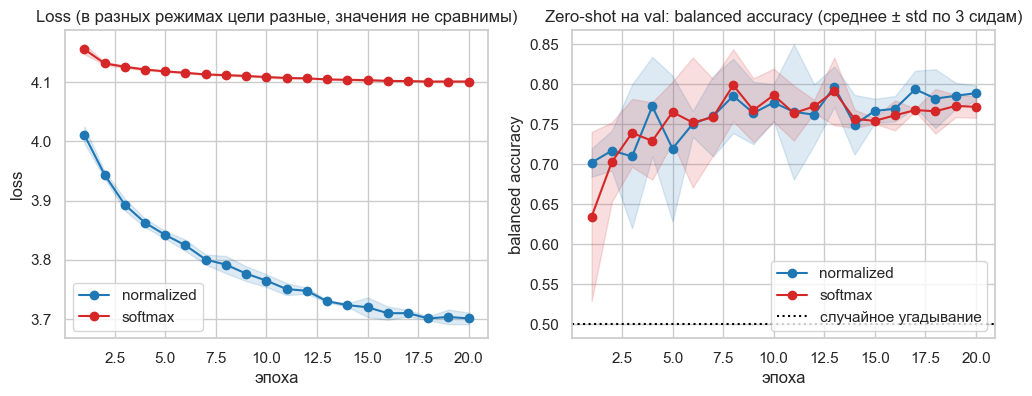

Итог после последней эпохи (val, zero-shot, balanced accuracy), среднее ± std по 3 сидам:
  normalized: 0.789 ± 0.010
  softmax   : 0.771 ± 0.014


In [43]:
colors = {"normalized": "tab:blue", "softmax": "tab:red"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mode, runs in trial.items():
    h = pd.concat([pd.DataFrame(r).assign(seed=s) for s, r in runs.items()])
    g_ = h.groupby("epoch")[["loss", "val_balanced_accuracy"]].agg(["mean", "std"])
    for ax, col in zip(axes, ["loss", "val_balanced_accuracy"]):
        m, sd = g_[col]["mean"], g_[col]["std"]
        ax.plot(g_.index, m, marker="o", color=colors[mode], label=mode)
        ax.fill_between(g_.index, m - sd, m + sd, color=colors[mode], alpha=0.15)
axes[0].set_title("Loss (в разных режимах цели разные, значения не сравнимы)")
axes[0].set_xlabel("эпоха"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[1].axhline(0.5, color="black", linestyle=":", label="случайное угадывание")
axes[1].set_title("Zero-shot на val: balanced accuracy (среднее ± std по 3 сидам)")
axes[1].set_xlabel("эпоха"); axes[1].set_ylabel("balanced accuracy"); axes[1].legend()
save_fig("12_medclip_loss_modes")
plt.show()

print("Итог после последней эпохи (val, zero-shot, balanced accuracy), среднее ± std по 3 сидам:")
for mode, runs in trial.items():
    vals = [r[-1]["val_balanced_accuracy"] for r in runs.values()]
    print(f"  {mode:10s}: {np.mean(vals):.3f} ± {np.std(vals, ddof=1):.3f}")

### 4.9. Основное обучение: 10 сидов

Теперь учим Mini-MedCLIP в лучшем режиме (`normalized`) на всех 10 сидах. Уже обученные модели (например, `seed = 13` из пробного запуска) не пересчитываются, а загружаются. Каждый сид — отдельный запуск с отдельным стартом, чтобы потом честно посчитать среднее и разброс.

In [ ]:
med_histories = {}
for seed in tqdm(SEEDS, desc="сиды Mini-MedCLIP"):
    _, med_histories[seed] = train_medclip(seed, xr_train_x, xr_val_x, xr_val_y, "A_radiology", "normalized", verbose=False)

hist_df = pd.concat([pd.DataFrame(h).assign(seed=s) for s, h in med_histories.items()], ignore_index=True)
hist_df.to_csv(RESULTS_DIR / "stage4_medclip_training_history.csv", index=False)

final = hist_df[hist_df["epoch"] == hist_df["epoch"].max()].set_index("seed")
print(f"Zero-shot на val после {hist_df['epoch'].max()} эпох (balanced accuracy):")
print(final["val_balanced_accuracy"].round(3).to_string())
print()
print(f"среднее ± std по {len(final)} сидам: "
      f"{final['val_balanced_accuracy'].mean():.3f} ± {final['val_balanced_accuracy'].std():.3f}")

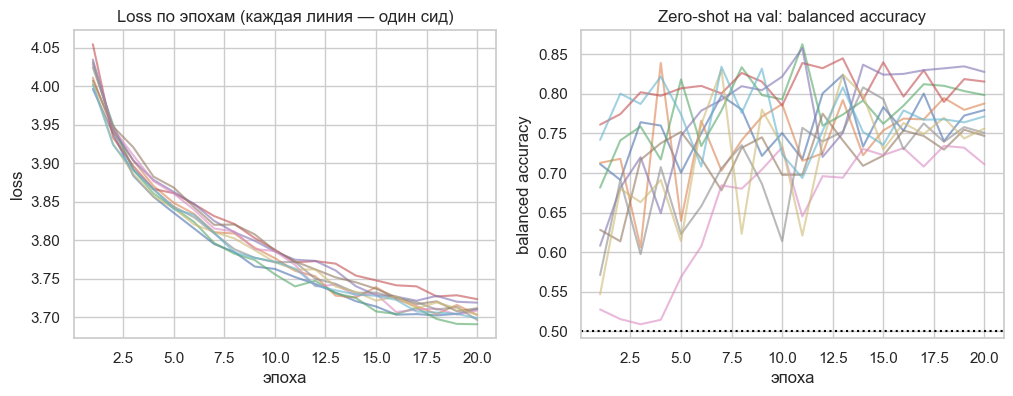

In [45]:
# Кривые обучения всех сидов: видно, одинаково ли они ведут себя
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for seed, h in med_histories.items():
    h = pd.DataFrame(h)
    axes[0].plot(h["epoch"], h["loss"], alpha=0.6)
    axes[1].plot(h["epoch"], h["val_balanced_accuracy"], alpha=0.6)
axes[0].set_title("Loss по эпохам (каждая линия — один сид)")
axes[0].set_xlabel("эпоха"); axes[0].set_ylabel("loss")
axes[1].axhline(0.5, color="black", linestyle=":")
axes[1].set_title("Zero-shot на val: balanced accuracy")
axes[1].set_xlabel("эпоха"); axes[1].set_ylabel("balanced accuracy")
save_fig("13_medclip_all_seeds")
plt.show()


1. Loss падает от эпохи к эпохе 
2. **Val balanced accuracy заметно выше 0.5.** Это значит, что Mini-MedCLIP научился отличать COVID от нормы *только по подписям*, без дообучения.
3. **Сравнение режимов (4.8).** Возможны два исхода, и оба — результат для отчёта:
   - `normalized` заметно лучше, то «размазанные» цели действительно мешали.
4. прыжки вверх-вниз между эпохами нормальны, потому что val небольшой (1376 снимков).

Теперь полная оценка на **test** (zero-shot, linear probe, few-shot) и сравнение с обычным MiniCLIP.

## Этап 5. Оценка на test: COVID против Normal

Сравниваем три модели на **тестовой выборке** (2753 снимка, модель их не видела):

| Модель | Что это |
|---|---|
| **MiniCLIP (CIFAR-10)** | обычный CLIP, обученный на CIFAR-10 (этап 3), заморожен |
| **MiniCLIP (без обучения)** | та же архитектура со случайными весами (нулевая точка отсчёта) |
| **Mini-MedCLIP** | наша модель на рентгенах (этап 4) |

Три способа проверки (как на этапе 3): 

**zero-shot** (по текстовым подписям)

 **linear probe** (линейный классификатор на всех train-снимках)
 
 **few-shot** (то же, но по k снимков каждого класса)

**Главная метрика: balanced accuracy** (0.5 = угадывание, 1.0 = идеально). Дополнительно accuracy и macro-F1. Все числа: среднее ± std по 10 сидам. Linear probe и few-shot обучаются с `class_weight="balanced"`, чтобы перекос классов (74% / 26%) не искажал результат.

In [ ]:
FEW_SHOT_KS_XRAY = [1, 2, 4, 8, 16, 32]
MODEL_CLIP, MODEL_RAND, MODEL_MED = "MiniCLIP (CIFAR-10)", "MiniCLIP (без обучения)", "Mini-MedCLIP"
MODELS_XR = [MODEL_CLIP, MODEL_RAND, MODEL_MED]
METHODS_XR = ["zero-shot"] + [f"{k}-shot" for k in FEW_SHOT_KS_XRAY] + ["linear-probe"]
train_y_np, test_y_np = xr_train_y.numpy(), xr_test_y.numpy()


In [ ]:
xr_rows, zs_sims = [], {}

def add_xr(rows, model, method, seed, metrics):
    for metric, value in metrics.items():
        rows.append({"model": model, "method": method, "seed": seed, "metric": metric, "value": value})

for seed in tqdm(SEEDS, desc="сиды"):
    medclip, _ = train_medclip(seed, xr_train_x, xr_val_x, xr_val_y, "A_radiology", "normalized", verbose=False)
    models = {
        MODEL_CLIP: (load_miniclip(seed, c10_train_x, c10_train_y, tokenizer),   tokenizer),
        MODEL_RAND: (make_untrained(seed, tokenizer),  tokenizer),
        MODEL_MED:  (medclip,               tok_A),
    }
    for name, (model, tok) in models.items():
        f_train = xray_features(model, xr_train_x)
        f_test  = xray_features(model, xr_test_x)

        # zero-shot
        metrics, sims = xray_zero_shot(model, tok, f_test, test_y_np)
        add_xr(xr_rows, name, "zero-shot", seed, metrics)
        if seed == SEEDS[0]:
            zs_sims[name] = sims

        # linear probe (все train-снимки)
        add_xr(xr_rows, name, "linear-probe", seed, xray_probe(f_train, train_y_np, f_test, test_y_np, seed))

        # few-shot (k снимков каждого класса; для всех моделей одни и те же снимки)
        rng = np.random.default_rng(seed)
        for k in FEW_SHOT_KS_XRAY:
            idx = sample_k_per_class(train_y_np, k, rng)
            add_xr(xr_rows, name, f"{k}-shot", seed,
                   xray_probe(f_train[idx], train_y_np[idx], f_test, test_y_np, seed))

xr_df = pd.DataFrame(xr_rows)
xr_df.to_csv(RESULTS_DIR / "stage5_covid_test.csv", index=False)
print("Готово, строк:", len(xr_df))

### 5.1. Результаты

In [ ]:
print("Balanced accuracy (главная метрика), среднее ± std по сидам")
display(summary_table(xr_df, "balanced_accuracy", MODELS_XR, METHODS_XR))
print("Accuracy (для справки: «всегда Normal» даёт 0.741)")
display(summary_table(xr_df, "accuracy", MODELS_XR, METHODS_XR))


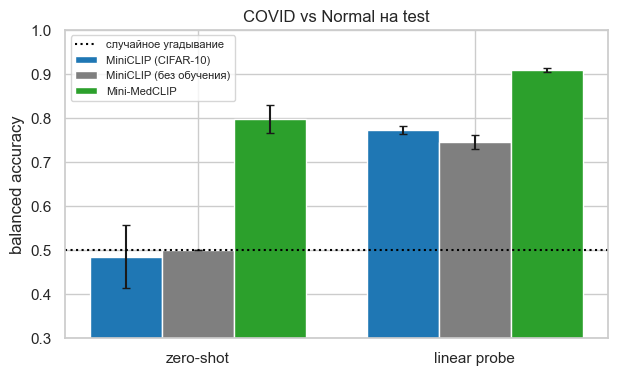

In [49]:
# График 1: zero-shot и linear probe
bal = xr_df[xr_df["metric"] == "balanced_accuracy"]
fig, ax = plt.subplots(figsize=(7, 4))
width = 0.26
colors = {MODEL_CLIP: "tab:blue", MODEL_RAND: "tab:gray", MODEL_MED: "tab:green"}
for j, model_name in enumerate(MODELS_XR):
    sub = bal[(bal["model"] == model_name) & bal["method"].isin(["zero-shot", "linear-probe"])]
    agg = sub.groupby("method")["value"].agg(["mean", "std"]).loc[["zero-shot", "linear-probe"]]
    ax.bar(np.arange(2) + (j - 1) * width, agg["mean"], width, yerr=agg["std"],
           capsize=3, label=model_name, color=colors[model_name])
ax.axhline(0.5, color="black", linestyle=":", label="случайное угадывание")
ax.set_xticks(range(2)); ax.set_xticklabels(["zero-shot", "linear probe"])
ax.set_ylabel("balanced accuracy"); ax.set_ylim(0.3, 1.0)
ax.set_title("COVID vs Normal на test")
ax.legend(loc="upper left", fontsize=8)
save_fig("14_xray_zeroshot_lp")
plt.show()

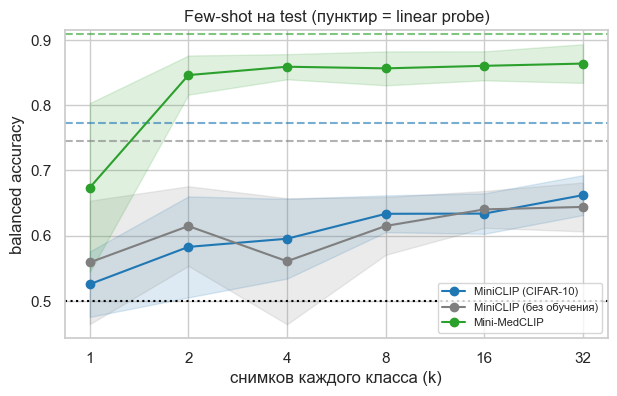

In [50]:
# График 2: few-shot (чем больше примеров на класс, тем лучше); пунктир = linear probe на всех данных
fig, ax = plt.subplots(figsize=(7, 4))
for model_name in MODELS_XR:
    sub = bal[bal["model"] == model_name]
    fs = (sub[sub["method"].str.endswith("-shot") & (sub["method"] != "zero-shot")]
          .assign(k=lambda d: d["method"].str.replace("-shot", "").astype(int))
          .groupby("k")["value"].agg(["mean", "std"]))
    ax.plot(fs.index, fs["mean"], marker="o", color=colors[model_name], label=model_name)
    ax.fill_between(fs.index, fs["mean"] - fs["std"], fs["mean"] + fs["std"], color=colors[model_name], alpha=0.15)
    ax.axhline(sub[sub["method"] == "linear-probe"]["value"].mean(), color=colors[model_name], linestyle="--", alpha=0.6)
ax.axhline(0.5, color="black", linestyle=":")
ax.set_xscale("log", base=2); ax.set_xticks(FEW_SHOT_KS_XRAY); ax.set_xticklabels(FEW_SHOT_KS_XRAY)
ax.set_xlabel("снимков каждого класса (k)"); ax.set_ylabel("balanced accuracy")
ax.set_title("Few-shot на test (пунктир = linear probe)")
ax.legend(fontsize=8)
save_fig("15_xray_fewshot")
plt.show()

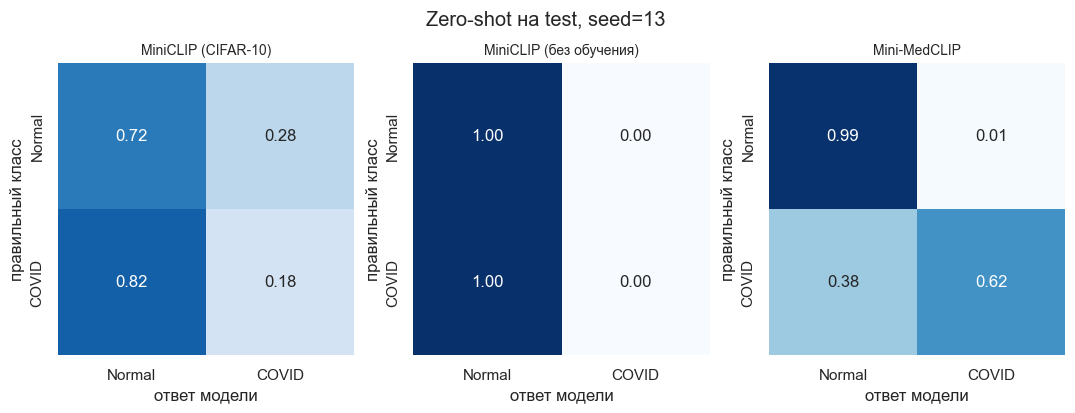

In [51]:
# Матрицы ошибок zero-shot (первый сид): что именно отвечает каждая модель
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, name in zip(axes, MODELS_XR):
    cm = confusion_matrix(test_y_np, zs_sims[name].argmax(axis=1), labels=[0, 1], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False, vmin=0, vmax=1, ax=ax,
                xticklabels=["Normal", "COVID"], yticklabels=["Normal", "COVID"])
    ax.set_title(name, fontsize=10); ax.set_xlabel("ответ модели"); ax.set_ylabel("правильный класс")
plt.suptitle(f"Zero-shot на test, seed={SEEDS[0]}", y=1.02)
save_fig("16_xray_zeroshot_confusion")
plt.show()

In [52]:
# Mini-MedCLIP лучше обычного MiniCLIP? Сравниваем по каждому сиду отдельно (парное сравнение)
for method in ["zero-shot", "linear-probe", "8-shot"]:
    x = bal[bal["method"] == method].pivot(index="seed", columns="model", values="value")
    d = x[MODEL_MED] - x[MODEL_CLIP]
    print(f"{method:13s}: Mini-MedCLIP минус MiniCLIP = {d.mean():+.3f} ± {d.std():.3f}   "
          f"(MedCLIP лучше в {(d > 0).sum()} из {len(d)} сидов)")

zero-shot    : Mini-MedCLIP минус MiniCLIP = +0.313 ± 0.065   (MedCLIP лучше в 10 из 10 сидов)
linear-probe : Mini-MedCLIP минус MiniCLIP = +0.136 ± 0.011   (MedCLIP лучше в 10 из 10 сидов)
8-shot       : Mini-MedCLIP минус MiniCLIP = +0.223 ± 0.032   (MedCLIP лучше в 10 из 10 сидов)


Если Mini-MedCLIP заметно выше MiniCLIP и выше «случайного» уровня 0.5 по всем трём способам, то доменная адаптация (обучение на рентгенах с метками) помогает. Разница между моделями должна быть больше разброса (±) по сидам

## Этап 6. Зависит ли результат от текстов (промптов)?

Обучаем Mini-MedCLIP на четырёх разных наборах текстов по 8 предложений (по 4 на каждый класс). Всё остальное одинаково: те же данные, loss `normalized`, 20 эпох, 10 сидов.

| Набор | Стиль |
|---|---|
| `A_radiology` | рентгенологические заключения (то, что использовали до сих пор) |
| `B_short` | короткие: «COVID-19 pneumonia.», «Normal lungs.» |
| `C_clinical` | длинные клинические описания |
| `D_template` | шаблоны как в CLIP: «a chest X-ray of a patient with COVID-19» |

Для каждого набора свои подписи для zero-shot, составленные только из слов этого набора (иначе модель их не знает, см. этап 3). Linear probe не использует текст, он покажет, влияют ли тексты на качество «зрения» модели.

In [ ]:
PROMPT_SETS["B_short"] = [
    ("COVID-19 chest X-ray.", 1), ("Chest X-ray of COVID-19 pneumonia.", 1),
    ("COVID-19 pneumonia.", 1), ("Coronavirus infection.", 1),
    ("Normal chest X-ray.", 0), ("Healthy lungs.", 0),
    ("Chest X-ray with no findings.", 0), ("No pneumonia.", 0),
]
ZERO_SHOT_BY_SET["B_short"] = {
    1: ["COVID-19 pneumonia.", "Chest X-ray with COVID-19.", "Coronavirus pneumonia."],
    0: ["Normal lungs.", "Healthy chest X-ray.", "Chest X-ray with normal lungs."],
}

PROMPT_SETS["C_clinical"] = [
    ("Multifocal bilateral ground-glass opacities with peripheral and lower lobe predominance, typical of COVID-19 pneumonia.", 1),
    ("Patchy bilateral airspace consolidation in a peripheral distribution, consistent with COVID-19 infection.", 1),
    ("Bilateral lower zone opacities and ground-glass change, findings are compatible with COVID-19 pneumonia.", 1),
    ("Diffuse bilateral pulmonary infiltrates with peripheral predominance suggest COVID-19 pneumonia.", 1),
    ("The lungs are clear bilaterally. The heart size is normal. No pleural effusion or pneumothorax.", 0),
    ("Normal chest radiograph. No focal consolidation, pleural effusion or pneumothorax.", 0),
    ("Clear lungs with normal cardiomediastinal silhouette. No acute cardiopulmonary abnormality.", 0),
    ("No active disease. The lungs are well expanded and clear, the heart size is normal.", 0),
]
ZERO_SHOT_BY_SET["C_clinical"] = {
    1: ["Bilateral opacities consistent with COVID-19 pneumonia.", "Findings are typical of COVID-19 infection.",
        "Peripheral ground-glass opacities with COVID-19 pneumonia."],
    0: ["Normal chest radiograph with clear lungs.", "The lungs are clear. No acute abnormality.",
        "No pleural effusion or pneumothorax. The heart size is normal."],
}

PROMPT_SETS["D_template"] = [
    ("a chest X-ray of a patient with COVID-19", 1), ("a photo of a chest X-ray with COVID-19 pneumonia", 1),
    ("an X-ray image showing COVID-19", 1), ("a COVID-19 chest X-ray", 1),
    ("a chest X-ray of a healthy patient", 0), ("a photo of a normal chest X-ray", 0),
    ("an X-ray image showing healthy lungs", 0), ("a normal chest X-ray", 0),
]
ZERO_SHOT_BY_SET["D_template"] = {
    1: ["a chest X-ray with COVID-19", "a photo of a COVID-19 chest X-ray", "an X-ray of a patient with COVID-19"],
    0: ["a chest X-ray of a normal patient", "a photo of a healthy chest X-ray", "an X-ray image showing normal lungs"],
}

# Проверка: все слова из zero-shot подписей есть в словаре своего набора
for name in PROMPT_SETS:
    tok, _, _ = get_prompt_data(name)
    unknown = sorted({w for cls in (0, 1) for p in ZERO_SHOT_BY_SET[name][cls]
                      for w in tok.tokenize(p) if w not in tok.stoi})
    print(f"{name:12s}: слов в словаре {len(tok.stoi):3d}, неизвестных в zero-shot подписях: {unknown or 'нет'}")
    assert not unknown, f"в наборе {name} есть неизвестные слова"

In [ ]:
PROMPT_NAMES = list(PROMPT_SETS)
p_rows = []
for name in PROMPT_NAMES:
    tok, _, _ = get_prompt_data(name)
    for seed in tqdm(SEEDS, desc=name):
        model, _ = train_medclip(seed, xr_train_x, xr_val_x, xr_val_y, name, "normalized", verbose=False)
        f_train = xray_features(model, xr_train_x)
        f_test  = xray_features(model, xr_test_x)
        metrics, _ = xray_zero_shot(model, tok, f_test, test_y_np, ZERO_SHOT_BY_SET[name])
        add_xr(p_rows, name, "zero-shot", seed, metrics)
        add_xr(p_rows, name, "linear-probe", seed, xray_probe(f_train, train_y_np, f_test, test_y_np, seed))

p_df = pd.DataFrame(p_rows)
p_df.to_csv(RESULTS_DIR / "stage6_prompt_sets_test.csv", index=False)

print("Balanced accuracy на test, среднее ± std по сидам")
display(summary_table(p_df, "balanced_accuracy", PROMPT_NAMES, ["zero-shot", "linear-probe"]))

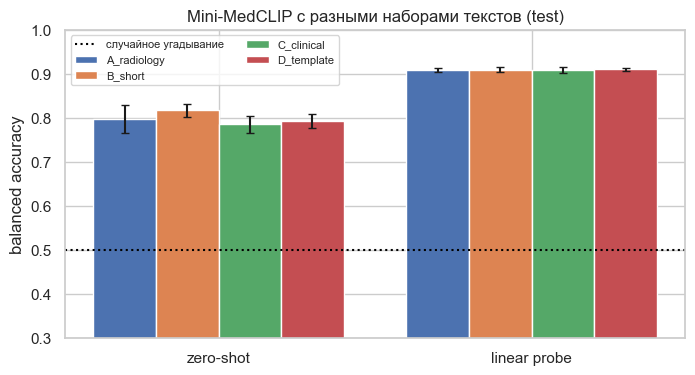

Отличие от A_radiology (balanced accuracy, среднее ± std по сидам):
  zero-shot    B_short    : +0.019 ± 0.034  (лучше A в 7 из 10 сидов)
  zero-shot    C_clinical : -0.013 ± 0.038  (лучше A в 4 из 10 сидов)
  zero-shot    D_template : -0.005 ± 0.026  (лучше A в 4 из 10 сидов)
  linear-probe B_short    : +0.000 ± 0.005  (лучше A в 6 из 10 сидов)
  linear-probe C_clinical : -0.000 ± 0.007  (лучше A в 5 из 10 сидов)
  linear-probe D_template : +0.001 ± 0.005  (лучше A в 6 из 10 сидов)


In [56]:
p_bal = p_df[p_df["metric"] == "balanced_accuracy"]
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.2
for j, name in enumerate(PROMPT_NAMES):
    agg = p_bal[p_bal["model"] == name].groupby("method")["value"].agg(["mean", "std"]).loc[["zero-shot", "linear-probe"]]
    ax.bar(np.arange(2) + (j - 1.5) * width, agg["mean"], width, yerr=agg["std"], capsize=3, label=name)
ax.axhline(0.5, color="black", linestyle=":", label="случайное угадывание")
ax.set_xticks(range(2)); ax.set_xticklabels(["zero-shot", "linear probe"])
ax.set_ylabel("balanced accuracy"); ax.set_ylim(0.3, 1.0)
ax.set_title("Mini-MedCLIP с разными наборами текстов (test)")
ax.legend(fontsize=8, loc="upper left", ncol=2)
save_fig("17_prompt_sets")
plt.show()

# Парное сравнение с набором A по каждому сиду
print("Отличие от A_radiology (balanced accuracy, среднее ± std по сидам):")
for method in ["zero-shot", "linear-probe"]:
    x = p_bal[p_bal["method"] == method].pivot(index="seed", columns="model", values="value")
    for name in PROMPT_NAMES[1:]:
        d = x[name] - x["A_radiology"]
        print(f"  {method:12s} {name:11s}: {d.mean():+.3f} ± {d.std():.3f}  (лучше A в {(d > 0).sum()} из {len(d)} сидов)")

## Этап 7. Сводка и ограничения

In [ ]:
# Ключевые числа(balanced accuracy, test, среднее ± std по сидам)

summary_rows = []
for model in MODELS_XR:
    summary_rows.append({"модель": model, "zero-shot": metric_summary(xr_df, model, "zero-shot"),
                         "8-shot": metric_summary(xr_df, model, "8-shot"), "linear probe": metric_summary(xr_df, model, "linear-probe")})
final_table = pd.DataFrame(summary_rows).set_index("модель")
final_table.to_csv(RESULTS_DIR / "final_table.csv")
display(final_table)